# Overview

In this notebook, we will go through the task generation pipeline in LIBERO. We will cover the following contents:

1. Retrieve a list of available objects, predicates
 in the codebase
2. Define your own initial state distribution
3. Define your own task goal
4. Generate the pddl file for the task

Now, let's get started!

## 1. Retrieve a list of objects available

In order for the sucess in task generation, we need to make sure that the objects and the predicates (object relations) specified are available in the codebase.

In [1]:
from libero.libero.envs.objects import get_object_dict, get_object_fn

# Get a dictionary of all the objects
object_dict = get_object_dict()
print(object_dict)

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/joe/miniconda3/envs/openvla-oft/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)


{'alphabet_soup': <class 'libero.libero.envs.objects.hope_objects.AlphabetSoup'>, 'bbq_sauce': <class 'libero.libero.envs.objects.hope_objects.BbqSauce'>, 'butter': <class 'libero.libero.envs.objects.hope_objects.Butter'>, 'cherries': <class 'libero.libero.envs.objects.hope_objects.Cherries'>, 'chocolate_pudding': <class 'libero.libero.envs.objects.hope_objects.ChocolatePudding'>, 'cookies': <class 'libero.libero.envs.objects.hope_objects.Cookies'>, 'corn': <class 'libero.libero.envs.objects.hope_objects.Corn'>, 'cream_cheese': <class 'libero.libero.envs.objects.hope_objects.CreamCheese'>, 'ketchup': <class 'libero.libero.envs.objects.hope_objects.Ketchup'>, 'macaroni_and_cheese': <class 'libero.libero.envs.objects.hope_objects.MacaroniAndCheese'>, 'mayo': <class 'libero.libero.envs.objects.hope_objects.Mayo'>, 'milk': <class 'libero.libero.envs.objects.hope_objects.Milk'>, 'orange_juice': <class 'libero.libero.envs.objects.hope_objects.OrangeJuice'>, 'popcorn': <class 'libero.libero.e

Now you can see all the available objects, you can retrieve the object class by specifying their categories (which are the keys in the dictionary)

In [2]:
category_name = "moka_pot"
object_cls = get_object_fn(category_name)
print(category_name, ": defined in the class ", object_cls)

moka_pot : defined in the class  <class 'libero.libero.envs.objects.turbosquid_objects.MokaPot'>


Similarly, you can retrieve the information about predicates.

In [3]:
from libero.libero.envs.predicates import get_predicate_fn_dict, get_predicate_fn

predicate_dict = get_predicate_fn_dict()
print(predicate_dict)
print("=============")
predicate_name = "on"
print(get_predicate_fn(predicate_name))


{'true': <libero.libero.envs.predicates.base_predicates.TruePredicateFn object at 0x77ad31f1d960>, 'false': <libero.libero.envs.predicates.base_predicates.FalsePredicateFn object at 0x77ad31f1d990>, 'in': <libero.libero.envs.predicates.base_predicates.In object at 0x77ad31f1d9c0>, 'on': <libero.libero.envs.predicates.base_predicates.On object at 0x77ad31f1d9f0>, 'up': <libero.libero.envs.predicates.base_predicates.Up object at 0x77ad31f1dd20>, 'printjointstate': <libero.libero.envs.predicates.base_predicates.PrintJointState object at 0x77ad31f1dde0>, 'open': <libero.libero.envs.predicates.base_predicates.Open object at 0x77ad31f1df30>, 'close': <libero.libero.envs.predicates.base_predicates.Close object at 0x77ad31f1e440>, 'turnon': <libero.libero.envs.predicates.base_predicates.TurnOn object at 0x77ad31f1e470>, 'turnoff': <libero.libero.envs.predicates.base_predicates.TurnOff object at 0x77ad31f1e4a0>}


## 2. Define your own initial state distribution

In [4]:
import numpy as np
from libero.libero.utils.bddl_generation_utils import get_xy_region_kwargs_list_from_regions_info
from libero.libero.utils.mu_utils import register_mu, InitialSceneTemplates
from libero.libero.utils.task_generation_utils import register_task_info, get_task_info, generate_bddl_from_task_info

@register_mu(scene_type="floor")
class FloorScene1(InitialSceneTemplates):
    def __init__(self):

        fixture_num_info = {
            "floor": 1
        }

        object_num_info = {
            "chocolate_pudding": 1,
            "basket": 1,
            "orange_juice": 1,
            "bbq_sauce": 1,
            "ketchup": 1,
            "salad_dressing": 1
        }

        super().__init__(
            workspace_name="floor",
            fixture_num_info=fixture_num_info,
            object_num_info=object_num_info
        )

    def define_regions(self):
        # Center position
        start_y = -0.16
        x_center = 0
        spacing = 0.09  # y-spacing between items
        offset = 0  # x-offset for zig-zag

        # Chocolate pudding (target object) - center
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center + 0.02, start_y],
                region_name="target_object_region",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Orange juice - above pudding, zig right
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center + offset, start_y + spacing],
                region_name="other_object_region_0",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # BBQ sauce - further above, zig left
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center - offset, start_y + 2 * spacing],
                region_name="other_object_region_1",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Ketchup - below pudding, zig right
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center + offset, start_y - spacing],
                region_name="other_object_region_2",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Salad Dressing - further below, zig left
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center - offset, start_y - 2 * spacing],
                region_name="other_object_region_3",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Basket - above everything
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[0, 0.26],
                region_name="bin_region",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        self.xy_region_kwargs_list = get_xy_region_kwargs_list_from_regions_info(self.regions)


    @property
    def init_states(self):
        return [
            ("On", "chocolate_pudding_1", "floor_target_object_region"),
            ("On", "orange_juice_1", "floor_other_object_region_0"),
            ("On", "bbq_sauce_1", "floor_other_object_region_1"),
            ("On", "ketchup_1", "floor_other_object_region_2"),
            ("On", "salad_dressing_1", "floor_other_object_region_3"),
            ("On", "basket_1", "floor_bin_region")
        ]


In [5]:
import numpy as np
from libero.libero.utils.bddl_generation_utils import get_xy_region_kwargs_list_from_regions_info
from libero.libero.utils.mu_utils import register_mu, InitialSceneTemplates
from libero.libero.utils.task_generation_utils import register_task_info, get_task_info, generate_bddl_from_task_info

@register_mu(scene_type="floor")
class FloorScene1(InitialSceneTemplates):
    def __init__(self):

        fixture_num_info = {
            "floor": 1
        }

        object_num_info = {
            "chocolate_pudding": 1,
            "basket": 1,
            "orange_juice": 1,
            "bbq_sauce": 1,
            "ketchup": 1,
            "salad_dressing": 1,
            "alphabet_soup": 1
        }

        super().__init__(
            workspace_name="floor",
            fixture_num_info=fixture_num_info,
            object_num_info=object_num_info
        )

    def define_regions(self):
        # Center position
        start_y = -0.16
        x_center = 0
        spacing = 0.09  # y-spacing between items
        offset = 0  # x-offset for zig-zag

        # Chocolate pudding (target object) - center
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center + 0.02, start_y],
                region_name="target_object_region",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Orange juice - above pudding, zig right
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center + offset, start_y + spacing],
                region_name="other_object_region_0",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # BBQ sauce - further above, zig left
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center - offset, start_y + 2 * spacing],
                region_name="other_object_region_1",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Ketchup - below pudding, zig right
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center + offset, start_y - spacing],
                region_name="other_object_region_2",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Salad Dressing - further below, zig left
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center - offset, start_y - 2 * spacing],
                region_name="other_object_region_3",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[x_center - offset, start_y + 3 * spacing],
                region_name="other_object_region_4",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        # Basket - above everything
        self.regions.update(
            self.get_region_dict(
                region_centroid_xy=[0, 0.26],
                region_name="bin_region",
                target_name=self.workspace_name,
                region_half_len=0.000001
            )
        )

        self.xy_region_kwargs_list = get_xy_region_kwargs_list_from_regions_info(self.regions)



    @property
    def init_states(self):
        return [
            ("On", "chocolate_pudding_1", "floor_target_object_region"),
            ("On", "orange_juice_1", "floor_other_object_region_0"),
            ("On", "bbq_sauce_1", "floor_other_object_region_1"),
            ("On", "ketchup_1", "floor_other_object_region_2"),
            ("On", "salad_dressing_1", "floor_other_object_region_3"),
            ("On", "alphabet_soup_1", "floor_other_object_region_4"),
            ("On", "basket_1", "floor_bin_region")
        ]


## 3. Define your own task goal

Now that you've defined the initial state distributions, you can specify a task goal based on the available objects and the potential goals it can acehive.

In [6]:
scene_name = "floor_scene1"
language = "Pick up the chocolate pudding and place it in the basket"
register_task_info(
    language=language,
    scene_name=scene_name,
    objects_of_interest=["chocolate_pudding_1", "basket_1"],
    goal_states=[
        ("In", "chocolate_pudding_1", "basket_1_contain_region")
    ]
)

The task goals will be temporarily saved in the variable `libero.libero.utils.task_generation_utils.TASK_INFO` in the format of namedtuple `libero.libero.utils.task_generation_utils.TaskInfoTuple`. This design aims to make it easy for batch creation of tasks.

In [7]:
# This is the default path to store all the pddl scene files. Here we store the files in the temporary folder. If you want to directly add files into the libero codebase, get the default path use the following commented lines:
# from libero.libero import get_libero_path
# YOUR_BDDL_FILE_PATH = get_libero_path("bddl_files")

YOUR_BDDL_FILE_PATH = "tmp/pddl_files"
bddl_file_names, failures = generate_bddl_from_task_info(folder=YOUR_BDDL_FILE_PATH)

print(bddl_file_names)

print("Encountered some failures: ", failures)


Succefully generated: 1
['tmp/pddl_files/FLOOR_SCENE1_pick_up_the_chocolate_pudding_and_place_it_in_the_basket.bddl']
Encountered some failures:  []


Now you can see the content of the pddl file name. (Notice that we named our variable with bddl, since we are actually using the bddl package from Behavior. However, bddl is a subset of pddl, so we stick to the word PDDL for consistency in our paper writing and avoid confusion to the community.)

In [8]:
with open(bddl_file_names[0], "r") as f:
    content = f.read()
print(content)

(define (problem LIBERO_Floor_Manipulation)
  (:domain robosuite)
  (:language Pick up the chocolate pudding and place it in the basket)
    (:regions
      (target_object_region
          (:target floor)
          (:ranges (
              (0.019999 -0.160001 0.020001 -0.159999)
            )
          )
          (:yaw_rotation (
              (0.0 0.0)
            )
          )
      )
      (other_object_region_0
          (:target floor)
          (:ranges (
              (-1e-06 -0.07000100000000001 1e-06 -0.069999)
            )
          )
          (:yaw_rotation (
              (0.0 0.0)
            )
          )
      )
      (other_object_region_1
          (:target floor)
          (:ranges (
              (-1e-06 0.01999899999999999 1e-06 0.02000099999999999)
            )
          )
          (:yaw_rotation (
              (0.0 0.0)
            )
          )
      )
      (other_object_region_2
          (:target floor)
          (:ranges (
              (-1e-06 -0.25000

In [ ]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image
bddl_file_name = '/home/joe/LIBERO/libero/libero/bddl_files/libero_object/pick_up_the_chocolate_pudding_and_place_it_in_the_basket.bddl'
env_args = {
    "bddl_file_name": bddl_file_name,
    "camera_heights": 256,
    "camera_widths": 256
}
env = OffScreenRenderEnv(**env_args)
states = []
for i in range(3):
    obs = env.reset()
    state = env.get_sim_state()
    states.append(state)
    #print(state)
    #print(obs['basket_1_pos'])
    #print(obs['chocolate_pudding_1_pos'])
print(states[0]==states[1])
print(states[0]==states[2])
# print(obs['object-state'].shape)
# dim = 0
# for key, value in obs.items():
#     if key != 'agentview_image' and key != 'robot0_eye_in_hand_image':
#         print(key)
#         print(value.size)
#         dim += value.size
# print(dim)

[ True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True False False  True  True  True  True  True
 False  True  True  True  True  True  True False False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
[ True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True False False  True  True  True  True  True
  True  True  True  True  True  True  True False False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True 

In [23]:
print(states[0])

[ 0.          0.         -0.16103739  0.         -2.44459747  0.
  2.2267522   0.78539816  0.020833   -0.020833   -0.12       -0.24
  0.035       0.          0.          0.          1.         -0.00717752
  0.25751268  0.035       0.70710678  0.          0.          0.70710678
  0.05       -0.1         0.035       0.5         0.5         0.5
  0.5        -0.15637038  0.05239538  0.035       0.70710678  0.
  0.          0.70710678  0.1        -0.2         0.035       0.5
  0.5         0.5         0.5         0.15        0.03        0.035
  0.5         0.5         0.5         0.5        -0.2        -0.08
  0.015       0.          0.          0.70710678  0.70710678  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.


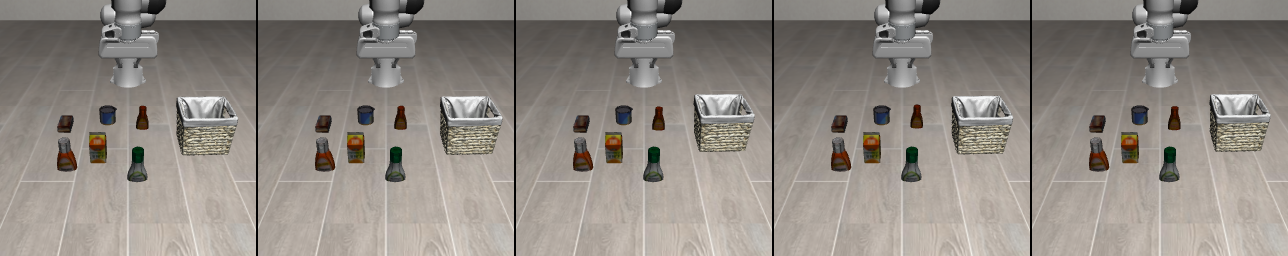

In [31]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image

import torch
import torchvision


env_args = {
    "bddl_file_name": bddl_file_name,
    "camera_heights": 256,
    "camera_widths": 256
}
env = OffScreenRenderEnv(**env_args)

def make_image_grid(images, nrow=8, padding=2, pad_value=0):
    """Creates a grid from a list of PIL Images."""
    if not images:
        raise ValueError("Image list is empty.")

    w, h = images[0].size
    ncols = nrow
    nrows = (len(images) + ncols - 1) // ncols

    grid_w = ncols * w + padding * (ncols - 1)
    grid_h = nrows * h + padding * (nrows - 1)

    # Background color for padding
    background = (pad_value, pad_value, pad_value)
    grid_img = Image.new("RGB", (grid_w, grid_h), color=background)

    for idx, img in enumerate(images):
        row = idx // ncols
        col = idx % ncols
        x = col * (w + padding)
        y = row * (h + padding)
        grid_img.paste(img, (x, y))

    return grid_img


images = []
states = []
for i in range(5):
    obs = env.reset()
    state = env.get_sim_state()
    states.append(state)
    img = Image.fromarray(obs["agentview_image"][::-1])
    images.append(img)

env.close()

# Create and display grid
grid_image = make_image_grid(images, nrow=5, padding=2, pad_value=0)
display(grid_image)

In [35]:
print(states[0]==states[2])
#print(states[1])

[ True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True False False  True  True  True  True  True
 False  True  True  True  True  True  True False False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
